In [ ]:
# Bài thực hành

In [ ]:
# Bài 1:

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, return_attn=False):
        # x: (batch, seq_len, embed_dim)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Tính ma trận tương đồng. transpose(-2, -1) đổi 2 chiều cuối.
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.embed_dim)
        attn = F.softmax(scores, dim=-1)             # (batch, seq_len, seq_len)
        out = attn @ V                               # (batch, seq_len, embed_dim)

        if return_attn:
            return out, attn
        return out

# Test trên một câu giả lập 5 token, mỗi token là vector 8 chiều.
sa = SelfAttention(embed_dim=8)
x = torch.randn(1, 5, 8)
out, attn = sa(x, return_attn=True)
print('Input shape :', x.shape)
print('Output shape:', out.shape)
print('Attn shape  :', attn.shape, '  (mỗi token ↔ mỗi token)')
print('Attn[0]     =\n', attn[0])
print('Tổng mỗi hàng (phải = 1):', attn[0].sum(dim=-1))

Input shape : torch.Size([1, 5, 8])
Output shape: torch.Size([1, 5, 8])
Attn shape  : torch.Size([1, 5, 5])   (mỗi token ↔ mỗi token)
Attn[0]     =
 tensor([[0.3571, 0.1273, 0.2532, 0.2217, 0.0407],
        [0.2283, 0.1779, 0.2365, 0.1824, 0.1750],
        [0.0857, 0.1879, 0.2146, 0.1882, 0.3236],
        [0.1231, 0.1535, 0.2547, 0.1542, 0.3146],
        [0.2047, 0.2722, 0.0709, 0.1445, 0.3076]], grad_fn=<SelectBackward0>)
Tổng mỗi hàng (phải = 1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


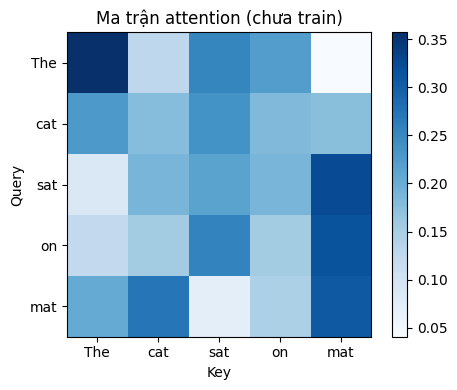

In [3]:
tokens = ['The', 'cat', 'sat', 'on', 'mat']
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn[0].detach().numpy(), cmap='Blues')
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(tokens); ax.set_yticklabels(tokens)
ax.set_xlabel('Key'); ax.set_ylabel('Query')
ax.set_title('Ma trận attention (chưa train)')
plt.colorbar(im); plt.tight_layout(); plt.show()

In [ ]:
# Bài 2:

In [4]:
# Mở rộng vocab và data so với bài LSTM, để có đủ tín hiệu.
from torch.nn.utils.rnn import pad_sequence

vocab = {'': 0, 'i': 1, 'you': 2, 'he': 3, 'we': 4, 'they': 5,
         'love': 6, 'like': 7, 'enjoy': 8, 'hate': 9, 'dislike': 10,
         'this': 11, 'that': 12, 'movie': 13, 'song': 14, 'food': 15,
         'place': 16, 'good': 17, 'bad': 18, 'great': 19, 'awful': 20,
         'not': 21, 'is': 22, 'so': 23, 'really': 24}

raw_data = [
    ('i love this movie',         1),
    ('we enjoy that song',         1),
    ('this food is great',         1),
    ('he likes the place',         1),  # không có 'the' trong vocab — bỏ qua khi encode
    ('they really love this',      1),
    ('i hate that movie',          0),
    ('this song is bad',           0),
    ('we dislike that food',       0),
    ('he is not good',             0),
    ('that place is awful',        0),
    ('this movie is so good',      1),
    ('i really enjoy this',        1),
    ('they hate this place',       0),
    ('that food is not great',     0),
    ('we love this song',          1),
    ('i dislike that movie',       0),
]

def encode(s):
    return [vocab[w] for w in s.lower().split() if w in vocab]

seqs   = [torch.tensor(encode(s), dtype=torch.long) for s, _ in raw_data]
labels = torch.tensor([y for _, y in raw_data], dtype=torch.long)
lengths = torch.tensor([len(s) for s in seqs])
X = pad_sequence(seqs, batch_first=True, padding_value=0)   # (N, max_len)
print('X shape:', X.shape, ' labels shape:', labels.shape)

X shape: torch.Size([16, 5])  labels shape: torch.Size([16])


In [5]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, num_heads=4, ffn_dim=64,
                 num_layers=2, num_classes=2, max_len=20):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Positional embedding học được — đơn giản hơn sin/cos, dùng cho seq ngắn.
        self.pos_emb   = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ffn_dim, dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x, src_key_padding_mask=None):
        # x: (B, T)
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        emb = self.token_emb(x) + self.pos_emb(positions)
        # padding mask: True ở vị trí padding để Transformer bỏ qua.
        out = self.encoder(emb, src_key_padding_mask=src_key_padding_mask)
        # Lấy trung bình theo seq dimension (loại bỏ vị trí padding khi tính trung bình).
        if src_key_padding_mask is not None:
            mask = (~src_key_padding_mask).float().unsqueeze(-1)
            pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = out.mean(dim=1)
        return self.fc(pooled)

model = TransformerClassifier(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng tham số: {n_params:,}')

Tổng tham số: 18,594


Epoch  40  loss = 0.0294  acc = 100.00%
Epoch  80  loss = 0.0032  acc = 100.00%
Epoch 120  loss = 0.0024  acc = 100.00%
Epoch 160  loss = 0.0018  acc = 100.00%
Epoch 200  loss = 0.0013  acc = 100.00%


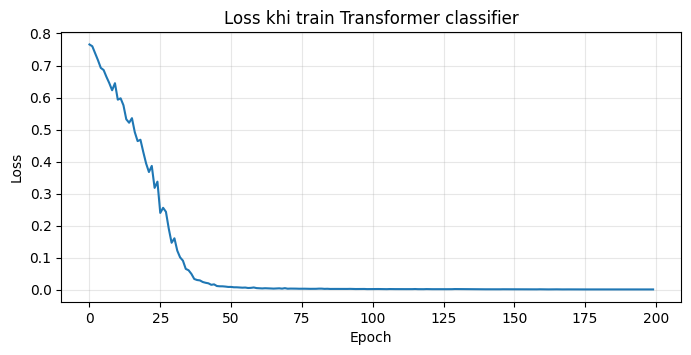

In [6]:
X, labels = X.to(device), labels.to(device)
padding_mask = (X == 0)   # True ở chỗ padding

loss_history = []
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    logits = model(X, src_key_padding_mask=padding_mask)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 40 == 0:
        acc = (logits.argmax(1) == labels).float().mean().item()
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}  acc = {acc*100:.2f}%')

plt.figure(figsize=(8, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train Transformer classifier'); plt.show()

In [7]:
# Predict trên câu KHÔNG có trong train.
model.eval()
test_sentences = [
    'we enjoy this song',
    'this movie is awful',
    'i hate that food',
    'they really like that place',
    'this is not good',
]
for s in test_sentences:
    ids = encode(s)
    seq = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    mask = (seq == 0)
    with torch.no_grad():
        logits = model(seq, src_key_padding_mask=mask)
        prob = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    label = 'Tích cực' if prob[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:30s}"  →  {label}  (P_pos = {prob[1]:.2f})')

"we enjoy this song            "  →  Tích cực  (P_pos = 1.00)
"this movie is awful           "  →  Tiêu cực  (P_pos = 0.00)
"i hate that food              "  →  Tiêu cực  (P_pos = 0.00)
"they really like that place   "  →  Tích cực  (P_pos = 0.99)
"this is not good              "  →  Tiêu cực  (P_pos = 0.00)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [ ]:
# Bài tập về nhà

In [ ]:
# Bài 1:

--- BƯỚC 2: QUÁ TRÌNH HUẤN LUYỆN HOÀN TẤT ---
Loss ở epoch cuối cùng: 0.0003

--- BƯỚC 3: PHÂN TÍCH MA TRẬN ATTENTION ---
Câu mẫu được trích xuất phân tích (Mẫu số 2): ['book', 'pad', 'good', 'the', 'pad', 'bad', 'not', 'movie']


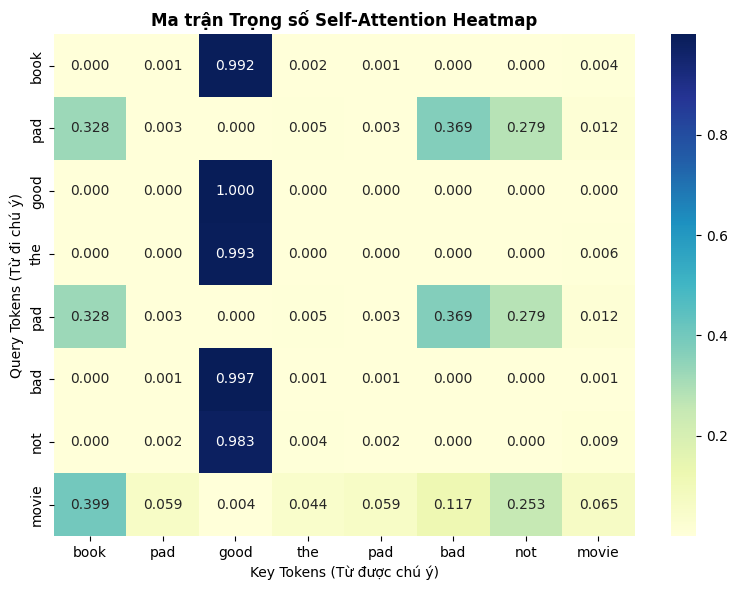

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập seed cố định để đảm bảo kết quả đồng nhất qua các lần chạy
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------------------------------------------------------
# 1. TỰ SINH DATASET ĐỒ CHƠI
# -------------------------------------------------------------------------
vocab = ["pad", "unk", "good", "bad", "movie", "book", "is", "not", "very", "the"]
vocab_size = len(vocab)
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for idx, word in enumerate(vocab)}

num_samples = 200
seq_len = 8

X_data = []
y_data = []

for _ in range(num_samples):
    # Chọn ngẫu nhiên các từ trong từ điển (trừ từ 'good' ra trước)
    possible_words = [w for w in vocab if w != "good"]
    sent_indices = [word_to_idx[np.random.choice(possible_words)] for _ in range(seq_len)]

    # Quyết định xem câu này có chứa từ "good" hay không (Tỷ lệ 50/50)
    has_good = np.random.rand() > 0.5
    if has_good:
        # Đặt từ "good" vào một vị trí ngẫu nhiên bất kỳ trong câu
        random_pos = np.random.randint(0, seq_len)
        sent_indices[random_pos] = word_to_idx["good"]
        label = 1
    else:
        label = 0

    X_data.append(sent_indices)
    y_data.append(label)

X_tensor = torch.LongTensor(X_data)
y_tensor = torch.FloatTensor(y_data).view(-1, 1)

# -------------------------------------------------------------------------
# 2. ĐỊNH NGHĨA LỚP SELF-ATTENTION VÀ PHÂN LOẠI
# -------------------------------------------------------------------------
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        # Tạo các ma trận hình chiếu tuyến tính cho Query, Key, Value
        self.q_linear = nn.Linear(embed_dim, embed_dim)
        self.k_linear = nn.Linear(embed_dim, embed_dim)
        self.v_linear = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, embed_dim)
        Q = self.q_linear(x)
        K = self.k_linear(x)
        V = self.v_linear(x)

        # Công thức Scaled Dot-Product Attention: Softmax( (Q * K^T) / sqrt(d_k) )
        # Biến đổi nhân ma trận: (B, S, D) x (B, D, S) -> (B, S, S)
        scores = torch.bmm(Q, K.transpose(1, 2)) / np.sqrt(self.embed_dim)
        attn_weights = torch.softmax(scores, dim=-1)

        # Nhân trọng số attention với ma trận Value: (B, S, S) x (B, S, D) -> (B, S, D)
        context = torch.bmm(attn_weights, V)
        return context, attn_weights

class AttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.attention = SelfAttention(embed_dim)
        # Lớp Fully Connected phân loại nhị phân đầu ra
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        out = self.embedding(x)
        # out: (batch_size, seq_len, embed_dim), weights: (batch_size, seq_len, seq_len)
        out, attn_weights = self.attention(out)

        # Gợi ý: Dùng "global pooling" (lấy mean qua chiều seq_len) thay vì dùng token CLS
        out = torch.mean(out, dim=1) # shape: (batch_size, embed_dim)

        return self.fc(out), attn_weights

# Khởi tạo mô hình mạng và cấu hình bộ tối ưu
model = AttentionClassifier(vocab_size=vocab_size).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Huấn luyện nhanh mô hình classifier
epochs = 40
X_tensor, y_tensor = X_tensor.to(device), y_tensor.to(device)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs, _ = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

print("--- BƯỚC 2: QUÁ TRÌNH HUẤN LUYỆN HOÀN TẤT ---")
print(f"Loss ở epoch cuối cùng: {loss.item():.4f}\n")

# -------------------------------------------------------------------------
# 3. TRÍCH XUẤT MA TRẬN ATTENTION VÀ VẼ HEATMAP
# -------------------------------------------------------------------------
model.eval()
with torch.no_grad():
    # Tìm câu đầu tiên có chứa nhãn là 1 (chắc chắn chứa từ "good") để trích xuất phân tích
    idx_sample = int(torch.where(y_tensor == 1)[0][0].item())
    sample_input = X_tensor[idx_sample : idx_sample + 1] # Thêm chiều batch_size = 1

    # Chạy mô hình để lấy ra ma trận trọng số attention weights
    _, attn_matrix = model(sample_input)
    # Loại bỏ chiều batch -> shape: (seq_len, seq_len)
    attn_matrix = attn_matrix.squeeze(0).cpu().numpy()

# Chuyển đổi các index số nguyên của câu mẫu thành chuỗi ký tự text để làm label đồ thị
sample_words = [idx_to_word[idx.item()] for idx in sample_input[0]]
print("--- BƯỚC 3: PHÂN TÍCH MA TRẬN ATTENTION ---")
print(f"Câu mẫu được trích xuất phân tích (Mẫu số {idx_sample}): {sample_words}")

# Tiến hành vẽ biểu đồ Heatmap bằng Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(attn_matrix, annot=True, fmt=".3f", cmap="YlGnBu",
            xticklabels=sample_words, yticklabels=sample_words)

plt.title("Ma trận Trọng số Self-Attention Heatmap", fontsize=12, fontweight='bold')
plt.xlabel("Key Tokens (Từ được chú ý)")
plt.ylabel("Query Tokens (Từ đi chú ý)")
plt.tight_layout()
plt.show()

In [ ]:
# Bài 2:

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time

# Thiết lập seed cố định để đảm bảo tính khách quan khi so sánh
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------------------------------------------------------
# 1. TẠO DATASET ĐỒ CHƠI "LONG-DEPENDENCY"
# -------------------------------------------------------------------------
vocab_size = 10  # Từ điển gồm 10 ký tự số (từ 0 đến 9)
seq_len = 30     # Độ dài chuỗi 30 tokens theo yêu cầu đề bài
num_samples = 1000

# Sinh ngẫu nhiên ma trận chuỗi số nguyên
X_np = np.random.randint(0, vocab_size, size=(num_samples, seq_len))
# Đề bài yêu cầu: nhãn = ký tự đầu tiên của chuỗi (Mô hình phải nhớ được phần tử đầu tiên này)
y_np = X_np[:, 0]

# Chia tập dữ liệu theo tỷ lệ 80% Train / 20% Test
split = int(num_samples * 0.8)
X_train, X_test = torch.LongTensor(X_np[:split]), torch.LongTensor(X_np[split:])
y_train, y_test = torch.LongTensor(y_np[:split]), torch.LongTensor(y_np[split:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

# -------------------------------------------------------------------------
# 2. XÂY DỰNG KIẾN TRÚC MẠNG TRANSFORMER ENCODER CLASSIFIER
# -------------------------------------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-np.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (batch_size, seq_len, embed_dim)
        return x + self.pe[:, :x.size(1)]

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, num_heads=2, hidden_dim=64, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoding(embed_dim)

        # Build 1 layer TransformerEncoder tiêu chuẩn theo mô tả
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # FC Layer phân loại ra số lượng nhãn tương ứng với số từ trong vocab
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        out = self.embedding(x)
        out = self.pos_encoder(out)
        out = self.transformer_encoder(out)
        # Sử dụng Global Pooling (lấy mean qua seq dim)
        out = torch.mean(out, dim=1)
        return self.fc(out)

# -------------------------------------------------------------------------
# 3. XÂY DỰNG KIẾN TRÚC MẠNG LSTM CLASSIFIER
# -------------------------------------------------------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        out = self.embedding(x)
        out, (h_n, c_n) = self.lstm(out)
        # Lấy hidden state cuối cùng đưa qua lớp tuyến tính phân loại
        return self.fc(h_n[-1])

# -------------------------------------------------------------------------
# 4. HÀM TỔNG QUÁT HÓA ĐO ĐẠC VÀ ĐÁNH GIÁ (WALL-CLOCK TIME & ACCURACY)
# -------------------------------------------------------------------------
def train_and_evaluate(model, name, epochs=20):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    # --- Đo thời gian chạy (Wall-clock time) của một Epoch ---
    model.train()
    start_time = time.time()

    # Chạy thử 1 epoch đầu tiên để đo đạc thời gian tính toán của kiến trúc mạng
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()

    end_time = time.time()
    epoch_time = end_time - start_time

    # Huấn luyện tiếp tục các epoch còn lại cùng số lượng vòng lặp
    for epoch in range(1, epochs):
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()

    # --- Đánh giá Accuracy trên tập kiểm thử Test ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x).argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = (correct / total) * 100
    return epoch_time, accuracy

# Tiến hành chạy thực nghiệm song song cho cả hai mô hình mạng
print("Đang huấn luyện và kiểm thử mô hình Transformer...")
time_tf, acc_tf = train_and_evaluate(TransformerClassifier(vocab_size), "Transformer")

print("Đang huấn luyện và kiểm thử mô hình LSTM...")
time_lstm, acc_lstm = train_and_evaluate(LSTMClassifier(vocab_size), "LSTM")

# -------------------------------------------------------------------------
# 5. XUẤT BÁO CÁO ĐỐI SÁNH KẾT QUẢ ĐỀ BÀI YÊU CẦU
# -------------------------------------------------------------------------
print("\n" + "="*65)
print(f"{'MÔ HÌNH MẠNG':<20} | {'TIME PER 1 EPOCH (s)':<22} | {'TEST ACCURACY':<15}")
print("="*65)
print(f"{'Transformer':<20} | {time_tf:<22.6f} | {acc_tf:<13.2f}%")
print(f"{'LSTM':<20} | {time_lstm:<22.6f} | {acc_lstm:<13.2f}%")
print("="*65)

Đang huấn luyện và kiểm thử mô hình Transformer...
Đang huấn luyện và kiểm thử mô hình LSTM...

MÔ HÌNH MẠNG         | TIME PER 1 EPOCH (s)   | TEST ACCURACY  
Transformer          | 0.271691               | 100.00       %
LSTM                 | 0.254138               | 8.50         %


In [ ]:
# Bài 3:

In [12]:
!pip install transformers datasets accelerate evaluate scikit-learn pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.0 MB/s eta 0:00:00


In [16]:
import os
import torch
import numpy as np

# Đảm bảo cài đặt các thư viện cần thiết lên hàng đầu trước khi import
try:
    import evaluate
except ImportError:
    import os
    os.system('pip install transformers datasets accelerate evaluate scikit-learn pyvi')
    import evaluate

from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

# Cấu hình seed cố định và thiết bị chạy (Ưu tiên GPU/CUDA)
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------------------------------------------------------
# 1. KHỞI TẠO DATASET TIẾNG VIỆT ĐỒ CHƠI
# -------------------------------------------------------------------------
print("--- BƯỚC 1: KHỞI TẠO TẬP DỮ LIỆU REVIEW TIẾNG VIỆT ---")

raw_reviews = [
    "Sản phẩm dùng rất tốt, đóng gói cẩn thận, giao hàng nhanh",
    "Chất lượng sản phẩm tuyệt vời, rất đáng tiền, nên mua nha mọi người",
    "Giao hàng nhanh chóng, nhân viên thân thiện, máy dùng mượt mà",
    "Shop phục vụ rất tốt, nhắn tin hỗ trợ nhiệt tình, 5 sao",
    "Sản phẩm xuất sắc, vượt mong đợi, dùng rất ưng ý",
    "Quá tệ, sản phẩm lỗi không dùng được, shop không chịu trách nhiệm",
    "Giao hàng quá chậm, đóng gói sơ sài, hộp bị móp méo hết",
    "Chất lượng kém, dùng được 2 ngày đã hỏng, phí tiền",
    "Sản phẩm không giống như mô tả, lừa đảo, không nên mua",
    "Hàng dùng rất chán, dịch vụ chăm sóc khách hàng quá dở",
    "Sản phẩm tạm ổn, giá cả phải chăng, giao hàng hơi lâu chút",
    "Màu sắc đẹp, đúng mẫu mã, dùng khá mượt",
    "Hàng giao đúng hẹn, đóng gói chắc chắn, dùng ok lắm",
    "Chất vải mát, mặc thoải mái, form tôn dáng",
    "Thiết kế đẹp mắt, sang trọng, rất thích hợp làm quà tặng",
    "Đế giày cứng quá, đi bị đau chân, không thoải mái chút nào",
    "Nhầm size rồi shop ơi, đổi trả thì phiền phức quá",
    "Sản phẩm có mùi nhựa rất nồng và hôi, không dám dùng luôn",
    "Giao thiếu phụ kiện đi kèm, làm ăn cẩu thả quá",
    "Mới dùng đã bong tróc hết sơn, hàng fake rồi"
]
raw_labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

# Chia thủ công thành tập Train (15 câu) và tập Test (5 câu)
X_train_raw, X_test_raw = raw_reviews[:15], raw_reviews[15:]
y_train, y_test = raw_labels[:15], raw_labels[15:]

# -------------------------------------------------------------------------
# 2. TOKENIZE BẰNG TOKENIZER CỦA PHOBERT
# -------------------------------------------------------------------------
print("\n--- BƯỚC 2: TIẾN HÀNH TOKENIZE VĂN BẢN VỚI PHOBERT TOKENIZER ---")
tokenizer = AutoTokenizer.from_pretrained('vinai/phobert-base', use_fast=False)

def tokenize_texts(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=64, return_tensors="pt")

train_encodings = tokenize_texts(X_train_raw)
test_encodings = tokenize_texts(X_test_raw)

class HuggingFaceSentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = HuggingFaceSentimentDataset(train_encodings, y_train)
test_dataset = HuggingFaceSentimentDataset(test_encodings, y_test)

# -------------------------------------------------------------------------
# 3. FINE-TUNE 2-3 EPOCH VỚI LR NHỎ (2e-5)
# -------------------------------------------------------------------------
print("\n--- BƯỚC 3: FINE-TUNE MÔ HÌNH PHOBERT (3 EPOCHS) ---")
model = AutoModelForSequenceClassification.from_pretrained('vinai/phobert-base', num_labels=2)

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Chỉ giữ lại 1 khối cấu hình tham số đúng chuẩn duy nhất, loại bỏ phần text thừa gây lỗi
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    eval_strategy="epoch",
    logging_steps=2,
    report_to="none"
)

# ĐÃ KHÔI PHỤC: Khởi tạo đối tượng Trainer bị thiếu ở code cũ của bạn
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Tiến hành chạy Fine-tune thực tế
trainer.train()

# -------------------------------------------------------------------------
# 4. BÁO CÁO ACCURACY + IN 5 VÍ DỤ PREDICT
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("--- BƯỚC 4: KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print("="*60)

eval_results = trainer.evaluate()
print(f"Độ chính xác (Accuracy) trên tập Test: {eval_results['eval_accuracy'] * 100:.2f}%\n")

trainer.model.eval()
print("CHI TIẾT 5 VÍ DỤ PREDICT THỰC TẾ:")
print("-" * 60)

sentiment_labels = {0: "TIÊU CỰC (Negative ❌)", 1: "TÍCH CỰC (Positive  )"}

with torch.no_grad():
    for i, text in enumerate(X_test_raw):
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=64).to(model.device)
        outputs = model(**inputs)
        pred_idx = torch.argmax(outputs.logits, dim=-1).item()

        print(f"Ví dụ {i+1}:")
        print(f" -> Câu review : \"{text}\"")
        print(f" -> Nhãn thực tế: {sentiment_labels[y_test[i]]}")
        print(f" -> Model đoán : {sentiment_labels[pred_idx]}")
        print("-" * 60)

--- BƯỚC 1: KHỞI TẠO TẬP DỮ LIỆU REVIEW TIẾNG VIỆT ---

--- BƯỚC 2: TIẾN HÀNH TOKENIZE VĂN BẢN VỚI PHOBERT TOKENIZER ---

--- BƯỚC 3: FINE-TUNE MÔ HÌNH PHOBERT (3 EPOCHS) ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/lo

Epoch,Training Loss,Validation Loss,Accuracy
1,0.703614,0.939107,0.000000
2,0.611250,0.997376,0.000000
3,0.589761,1.004126,0.000000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- BƯỚC 4: KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.589761,1.004126,3,0.000000


Độ chính xác (Accuracy) trên tập Test: 0.00%

CHI TIẾT 5 VÍ DỤ PREDICT THỰC TẾ:
------------------------------------------------------------
Ví dụ 1:
 -> Câu review : "Đế giày cứng quá, đi bị đau chân, không thoải mái chút nào"
 -> Nhãn thực tế: TIÊU CỰC (Negative ❌)
 -> Model đoán : TÍCH CỰC (Positive  )
------------------------------------------------------------
Ví dụ 2:
 -> Câu review : "Nhầm size rồi shop ơi, đổi trả thì phiền phức quá"
 -> Nhãn thực tế: TIÊU CỰC (Negative ❌)
 -> Model đoán : TÍCH CỰC (Positive  )
------------------------------------------------------------
Ví dụ 3:
 -> Câu review : "Sản phẩm có mùi nhựa rất nồng và hôi, không dám dùng luôn"
 -> Nhãn thực tế: TIÊU CỰC (Negative ❌)
 -> Model đoán : TÍCH CỰC (Positive  )
------------------------------------------------------------
Ví dụ 4:
 -> Câu review : "Giao thiếu phụ kiện đi kèm, làm ăn cẩu thả quá"
 -> Nhãn thực tế: TIÊU CỰC (Negative ❌)
 -> Model đoán : TÍCH CỰC (Positive  )
----------------------------------

In [ ]:
# Bài 4:

In [ ]:
"""1. Transformer ban đầu được thiết kế cho task gì ?
=> Ban đầu được thiết kế cho tác vụ Dịch máy ngôn ngữ tự nhiên

2. Encoder và Decoder khác nhau chỗ nào ?
=> Đối với Encoder: Tiếp nhận đầu vào cùng lúc và xử lý song song, dùng cơ chế Standard Self-Attention cho tương tác cả 2 chiều.
=> Đối với Decoder: Sinh chuỗi ký tự đầu ra một cách tuần tự, lai thêm lớp Masked Self-Attentionowr tầng đầu tiên để che ngữ cảnh,
bổ sung thêm lớp Encoder-Decoder Attention ở giữa để làm cầu nối: Lấy Query từ Decoder kết hợp với Key và Value truyền sang từ Encoder,
giúp Decoder vừa biết mình đã dịch đến đâu, vừa hiểu được nghĩa câu gốc từ Encoder.

3. Masked Self-Attention trong Decoder dùng để làm gì?
=> Ngăn không cho mô hình thấy các từ phía sau tại thời điểm tính toán.
"